In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/Diego/Paper Interpretability')
print(os.getcwd())

/content/drive/MyDrive/Colab Notebooks/Diego/Paper Interpretability


In [ ]:
!pip install optuna
!pip install lime
!pip install tf-keras-vis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=f84d268870b39324d8c0ddb75fe1da32fe15c9684964b9fe942ffd3e8c466b12
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 2.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd


def compute_faithfulness_auc_summary(
    df_plot_ready,
    early_max_percentage=None,
):
    """
    Calcula AUC de MoRF y ROAD por:
        paradigm, window, subject, fold, model, method

    Si early_max_percentage=None:
        usa todo el rango disponible, por ejemplo 0-100.

    Si early_max_percentage=30:
        usa solo 0-30%.
    """

    df = df_plot_ready.copy()

    if early_max_percentage is not None:
        df = df[df["percentage_removed"] <= early_max_percentage].copy()

    group_cols = [
        "paradigm",
        "window",
        "subject",
        "fold",
        "model",
        "method",
    ]

    rows = []

    for keys, g in df.groupby(group_cols, dropna=False):

        g = g.sort_values("percentage_removed")

        x = g["percentage_removed"].values / 100.0

        morf_auc = np.trapz(
            g["MoRF_accuracy"].values,
            x,
        )

        road_auc = np.trapz(
            g["ROAD_accuracy_gap"].values,
            x,
        )

        row = dict(zip(group_cols, keys))

        row.update({
            "MoRF_accuracy_AUC": morf_auc,
            "ROAD_accuracy_gap_AUC": road_auc,
        })

        rows.append(row)

    return pd.DataFrame(rows)


def aggregate_auc_by_window_model_method(df_auc):
    """
    Agrega los AUC por:
        paradigm, window, model, method

    Para MI:
        media ± std entre sujetos.

    Para TDAH:
        si hay un solo fold, std queda NaN.
    """

    df_summary = (
        df_auc
        .groupby(
            ["paradigm", "window", "model", "method"],
            as_index=False,
        )
        .agg(
            MoRF_accuracy_AUC_mean=("MoRF_accuracy_AUC", "mean"),
            MoRF_accuracy_AUC_std=("MoRF_accuracy_AUC", "std"),
            ROAD_accuracy_gap_AUC_mean=("ROAD_accuracy_gap_AUC", "mean"),
            ROAD_accuracy_gap_AUC_std=("ROAD_accuracy_gap_AUC", "std"),
            n_cases=("MoRF_accuracy_AUC", "count"),
        )
    )

    return df_summary


def pretty_model_name(model_name):
    model_map = {
        "shallowconvnet": "ShallowConvNet",
        "tgarnet": "T-GARNet",
        "eegnet": "EEGNet",
    }

    return model_map.get(model_name, model_name)


def get_ranked_morf_by_window(
    df_auc_summary,
    window_name,
):
    """
    Para una ventana específica, devuelve el ranking MoRF AUC
    por cada modelo.

    Criterio:
        Menor MoRF_accuracy_AUC_mean = mejor.
    """

    df_w = df_auc_summary[
        df_auc_summary["window"].astype(str) == str(window_name)
    ].copy()

    if df_w.empty:
        raise ValueError(f"No hay datos para window={window_name}")

    df_w["model_pretty"] = df_w["model"].apply(pretty_model_name)

    df_w = df_w.sort_values(
        ["model", "MoRF_accuracy_AUC_mean"],
        ascending=[True, True],
    )

    df_w["rank_MoRF"] = (
        df_w
        .groupby("model")["MoRF_accuracy_AUC_mean"]
        .rank(method="dense", ascending=True)
        .astype(int)
    )

    return df_w[
        [
            "window",
            "model_pretty",
            "method",
            "rank_MoRF",
            "MoRF_accuracy_AUC_mean",
            "MoRF_accuracy_AUC_std",
            "n_cases",
        ]
    ].rename(
        columns={
            "model_pretty": "model",
            "method": "strategy",
        }
    )


def get_ranked_road_by_window(
    df_auc_summary,
    window_name,
):
    """
    Para una ventana específica, devuelve el ranking ROAD AUC
    por cada modelo.

    Criterio:
        Mayor ROAD_accuracy_gap_AUC_mean = mejor.
    """

    df_w = df_auc_summary[
        df_auc_summary["window"].astype(str) == str(window_name)
    ].copy()

    if df_w.empty:
        raise ValueError(f"No hay datos para window={window_name}")

    df_w["model_pretty"] = df_w["model"].apply(pretty_model_name)

    df_w = df_w.sort_values(
        ["model", "ROAD_accuracy_gap_AUC_mean"],
        ascending=[True, False],
    )

    df_w["rank_ROAD"] = (
        df_w
        .groupby("model")["ROAD_accuracy_gap_AUC_mean"]
        .rank(method="dense", ascending=False)
        .astype(int)
    )

    return df_w[
        [
            "window",
            "model_pretty",
            "method",
            "rank_ROAD",
            "ROAD_accuracy_gap_AUC_mean",
            "ROAD_accuracy_gap_AUC_std",
            "n_cases",
        ]
    ].rename(
        columns={
            "model_pretty": "model",
            "method": "strategy",
        }
    )


def print_rankings_for_window(
    df_auc_summary,
    window_name,
):
    """
    Imprime dos tablas para una ventana:

        1. Ranking MoRF AUC
        2. Ranking ROAD AUC
    """

    print("=" * 90)
    print(f"WINDOW: {window_name}")
    print("=" * 90)

    print("\nMoRF AUC ranking")
    print("Criterio: menor MoRF_accuracy_AUC_mean = mejor\n")

    df_morf = get_ranked_morf_by_window(
        df_auc_summary=df_auc_summary,
        window_name=window_name,
    )

    display(df_morf)

    print("\nROAD AUC ranking")
    print("Criterio: mayor ROAD_accuracy_gap_AUC_mean = mejor\n")

    df_road = get_ranked_road_by_window(
        df_auc_summary=df_auc_summary,
        window_name=window_name,
    )

    display(df_road)

    return df_morf, df_road


def get_best_only_by_window(
    df_auc_summary,
    window_name,
):
    """
    Devuelve solo el mejor método por modelo para una ventana,
    separado para MoRF y ROAD.
    """

    df_morf = get_ranked_morf_by_window(
        df_auc_summary=df_auc_summary,
        window_name=window_name,
    )

    df_road = get_ranked_road_by_window(
        df_auc_summary=df_auc_summary,
        window_name=window_name,
    )

    best_morf = (
        df_morf[df_morf["rank_MoRF"] == 1]
        .copy()
        .sort_values("model")
    )

    best_road = (
        df_road[df_road["rank_ROAD"] == 1]
        .copy()
        .sort_values("model")
    )

    return best_morf, best_road
import pandas as pd
import numpy as np


def compute_average_rank_by_window_metric(
    df_auc_summary,
    windows=("2.5-5", "0-7", "TDAH"),
):
    """
    Calcula la posición promedio de cada estrategia XAI por ventana
    y por métrica.

    Usa df_auc_summary con columnas:
        window
        model
        method
        MoRF_accuracy_AUC_mean
        ROAD_accuracy_gap_AUC_mean

    Criterios:
        MoRF:
            menor MoRF_accuracy_AUC_mean = mejor posición

        ROAD:
            mayor ROAD_accuracy_gap_AUC_mean = mejor posición
    """

    rows = []

    for window_name in windows:

        df_w = df_auc_summary[
            df_auc_summary["window"].astype(str) == str(window_name)
        ].copy()

        if df_w.empty:
            print(f"[WARNING] No hay datos para window={window_name}")
            continue

        # ====================================================
        # Ranking MoRF por modelo
        # Menor AUC = mejor
        # ====================================================

        df_morf = df_w.copy()

        df_morf["rank"] = (
            df_morf
            .groupby("model")["MoRF_accuracy_AUC_mean"]
            .rank(method="dense", ascending=True)
        )

        for method_name, g in df_morf.groupby("method"):

            rows.append({
                "window": window_name,
                "metric": "MoRF",
                "method": method_name,
                "mean_rank": g["rank"].mean(),
                "std_rank": g["rank"].std(),
                "min_rank": g["rank"].min(),
                "max_rank": g["rank"].max(),
                "n_models": g["model"].nunique(),
                "mean_AUC": g["MoRF_accuracy_AUC_mean"].mean(),
                "std_AUC": g["MoRF_accuracy_AUC_mean"].std(),
            })

        # ====================================================
        # Ranking ROAD por modelo
        # Mayor AUC = mejor
        # ====================================================

        df_road = df_w.copy()

        df_road["rank"] = (
            df_road
            .groupby("model")["ROAD_accuracy_gap_AUC_mean"]
            .rank(method="dense", ascending=False)
        )

        for method_name, g in df_road.groupby("method"):

            rows.append({
                "window": window_name,
                "metric": "ROAD",
                "method": method_name,
                "mean_rank": g["rank"].mean(),
                "std_rank": g["rank"].std(),
                "min_rank": g["rank"].min(),
                "max_rank": g["rank"].max(),
                "n_models": g["model"].nunique(),
                "mean_AUC": g["ROAD_accuracy_gap_AUC_mean"].mean(),
                "std_AUC": g["ROAD_accuracy_gap_AUC_mean"].std(),
            })

    df_rank = pd.DataFrame(rows)

    df_rank = df_rank.sort_values(
        ["window", "metric", "mean_rank", "mean_AUC"],
        ascending=[True, True, True, False],
    ).reset_index(drop=True)

    return df_rank

In [ ]:
df_auc = compute_faithfulness_auc_summary(
    df_plot_ready=df_plot_ready,
    early_max_percentage=None,  # usa todo 0-100
)

df_auc_summary = aggregate_auc_by_window_model_method(df_auc)

/tmp/ipykernel_720/3324302344.py:42: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  morf_auc = np.trapz(
/tmp/ipykernel_720/3324302344.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  road_auc = np.trapz(


In [ ]:
morf_25_5, road_25_5 = print_rankings_for_window(
    df_auc_summary=df_auc_summary,
    window_name="2.5-5",
)

WINDOW: 2.5-5

MoRF AUC ranking
Criterio: menor MoRF_accuracy_AUC_mean = mejor



,window,model,strategy,rank_MoRF,MoRF_accuracy_AUC_mean,MoRF_accuracy_AUC_std,n_cases
14,2.5-5,ShallowConvNet,KernelSHAP,1,0.502500,NaN,1
15,2.5-5,ShallowConvNet,LIME,1,0.502500,NaN,1
16,2.5-5,ShallowConvNet,Occlusion,2,0.512500,NaN,1
13,2.5-5,ShallowConvNet,IntegratedGradients,3,0.584875,NaN,1
17,2.5-5,ShallowConvNet,STF-KernelSHAP,4,0.663750,NaN,1
12,2.5-5,ShallowConvNet,GradCAM++,5,0.800000,NaN,1
20,2.5-5,T-GARNet,KernelSHAP,1,0.502500,NaN,1
21,2.5-5,T-GARNet,LIME,1,0.502500,NaN,1
22,2.5-5,T-GARNet,Occlusion,2,0.516500,NaN,1
19,2.5-5,T-GARNet,IntegratedGradients,3,0.680375,NaN,1



ROAD AUC ranking
Criterio: mayor ROAD_accuracy_gap_AUC_mean = mejor



,window,model,strategy,rank_ROAD,ROAD_accuracy_gap_AUC_mean,ROAD_accuracy_gap_AUC_std,n_cases
16,2.5-5,ShallowConvNet,Occlusion,1,0.413750,NaN,1
13,2.5-5,ShallowConvNet,IntegratedGradients,2,0.326375,NaN,1
17,2.5-5,ShallowConvNet,STF-KernelSHAP,3,0.255000,NaN,1
12,2.5-5,ShallowConvNet,GradCAM++,4,0.070000,NaN,1
15,2.5-5,ShallowConvNet,LIME,5,0.023625,NaN,1
14,2.5-5,ShallowConvNet,KernelSHAP,6,0.000000,NaN,1
22,2.5-5,T-GARNet,Occlusion,1,0.399750,NaN,1
19,2.5-5,T-GARNet,IntegratedGradients,2,0.212125,NaN,1
23,2.5-5,T-GARNet,STF-KernelSHAP,3,0.056500,NaN,1
20,2.5-5,T-GARNet,KernelSHAP,4,0.000000,NaN,1


In [ ]:
morf_0_7, road_0_7 = print_rankings_for_window(
    df_auc_summary=df_auc_summary,
    window_name="0-7",
)

WINDOW: 0-7

MoRF AUC ranking
Criterio: menor MoRF_accuracy_AUC_mean = mejor



,window,model,strategy,rank_MoRF,MoRF_accuracy_AUC_mean,MoRF_accuracy_AUC_std,n_cases
2,0-7,ShallowConvNet,KernelSHAP,1,0.502500,NaN,1
3,0-7,ShallowConvNet,LIME,1,0.502500,NaN,1
4,0-7,ShallowConvNet,Occlusion,2,0.546625,NaN,1
5,0-7,ShallowConvNet,STF-KernelSHAP,3,0.571250,NaN,1
1,0-7,ShallowConvNet,IntegratedGradients,4,0.576750,NaN,1
0,0-7,ShallowConvNet,GradCAM++,5,0.795000,NaN,1
8,0-7,T-GARNet,KernelSHAP,1,0.502250,NaN,1
9,0-7,T-GARNet,LIME,1,0.502250,NaN,1
6,0-7,T-GARNet,GradCAM++,2,0.611000,NaN,1
10,0-7,T-GARNet,Occlusion,3,0.636000,NaN,1



ROAD AUC ranking
Criterio: mayor ROAD_accuracy_gap_AUC_mean = mejor



,window,model,strategy,rank_ROAD,ROAD_accuracy_gap_AUC_mean,ROAD_accuracy_gap_AUC_std,n_cases
4,0-7,ShallowConvNet,Occlusion,1,0.423375,NaN,1
1,0-7,ShallowConvNet,IntegratedGradients,2,0.398250,NaN,1
0,0-7,ShallowConvNet,GradCAM++,3,0.100000,NaN,1
5,0-7,ShallowConvNet,STF-KernelSHAP,4,0.096625,NaN,1
2,0-7,ShallowConvNet,KernelSHAP,5,0.000000,NaN,1
3,0-7,ShallowConvNet,LIME,5,0.000000,NaN,1
11,0-7,T-GARNet,STF-KernelSHAP,1,0.136750,NaN,1
9,0-7,T-GARNet,LIME,2,0.070875,NaN,1
10,0-7,T-GARNet,Occlusion,3,0.066000,NaN,1
7,0-7,T-GARNet,IntegratedGradients,4,0.064625,NaN,1


In [ ]:
morf_tdah, road_tdah = print_rankings_for_window(
    df_auc_summary=df_auc_summary,
    window_name="TDAH",
)

WINDOW: TDAH

MoRF AUC ranking
Criterio: menor MoRF_accuracy_AUC_mean = mejor



,window,model,strategy,rank_MoRF,MoRF_accuracy_AUC_mean,MoRF_accuracy_AUC_std,n_cases
28,TDAH,ShallowConvNet,Occlusion,1,0.536278,NaN,1
26,TDAH,ShallowConvNet,KernelSHAP,2,0.540998,NaN,1
27,TDAH,ShallowConvNet,LIME,3,0.547254,NaN,1
25,TDAH,ShallowConvNet,IntegratedGradients,4,0.612297,NaN,1
24,TDAH,ShallowConvNet,GradCAM++,5,0.771763,NaN,1
29,TDAH,ShallowConvNet,STF-KernelSHAP,6,0.810181,NaN,1
32,TDAH,T-GARNet,KernelSHAP,1,0.541941,NaN,1
33,TDAH,T-GARNet,LIME,2,0.548638,NaN,1
34,TDAH,T-GARNet,Occlusion,3,0.572149,NaN,1
30,TDAH,T-GARNet,GradCAM++,4,0.640750,NaN,1



ROAD AUC ranking
Criterio: mayor ROAD_accuracy_gap_AUC_mean = mejor



,window,model,strategy,rank_ROAD,ROAD_accuracy_gap_AUC_mean,ROAD_accuracy_gap_AUC_std,n_cases
25,TDAH,ShallowConvNet,IntegratedGradients,1,0.184201,NaN,1
27,TDAH,ShallowConvNet,LIME,2,0.093623,NaN,1
24,TDAH,ShallowConvNet,GradCAM++,3,0.001772,NaN,1
26,TDAH,ShallowConvNet,KernelSHAP,4,-0.002652,NaN,1
29,TDAH,ShallowConvNet,STF-KernelSHAP,5,-0.005368,NaN,1
28,TDAH,ShallowConvNet,Occlusion,6,-0.014572,NaN,1
30,TDAH,T-GARNet,GradCAM++,1,0.069846,NaN,1
31,TDAH,T-GARNet,IntegratedGradients,2,0.068623,NaN,1
33,TDAH,T-GARNet,LIME,3,0.066965,NaN,1
34,TDAH,T-GARNet,Occlusion,4,0.042134,NaN,1


In [ ]:
df_average_rank = compute_average_rank_by_window_metric(
    df_auc_summary=df_auc_summary,
    windows=("2.5-5", "0-7", "TDAH"),
)

df_average_rank[df_average_rank['method']=='STF-KernelSHAP']

,window,metric,method,mean_rank,std_rank,min_rank,max_rank,n_models,mean_AUC,std_AUC
4,0-7,MoRF,STF-KernelSHAP,3.5,0.707107,3.0,4.0,2,0.623812,0.074335
7,0-7,ROAD,STF-KernelSHAP,2.5,2.121320,1.0,4.0,2,0.116687,0.028373
17,2.5-5,MoRF,STF-KernelSHAP,4.5,0.707107,4.0,5.0,2,0.723875,0.085030
20,2.5-5,ROAD,STF-KernelSHAP,3.0,0.000000,3.0,3.0,2,0.155750,0.140361
29,TDAH,MoRF,STF-KernelSHAP,6.0,0.000000,6.0,6.0,2,0.832693,0.031837
35,TDAH,ROAD,STF-KernelSHAP,5.5,0.707107,5.0,6.0,2,-0.024961,0.027709


In [ ]:
df_average_rank = compute_average_rank_by_window_metric(
    df_auc_summary=df_auc_summary,
    windows=("2.5-5", "0-7", "TDAH"),
)

df_average_rank[df_average_rank['method']=='STF-KernelSHAP']

,window,metric,method,mean_rank,std_rank,min_rank,max_rank,n_models,mean_AUC,std_AUC
3,0-7,MoRF,STF-KernelSHAP,3.5,3.535534,1.0,6.0,2,0.450250,0.247841
6,0-7,ROAD,STF-KernelSHAP,1.5,0.707107,1.0,2.0,2,0.469312,0.293891
14,2.5-5,MoRF,STF-KernelSHAP,3.0,0.000000,3.0,3.0,2,0.402062,0.099967
20,2.5-5,ROAD,STF-KernelSHAP,2.5,0.707107,2.0,3.0,2,0.560438,0.140626
28,TDAH,MoRF,STF-KernelSHAP,5.5,0.707107,5.0,6.0,2,0.719801,0.129317
31,TDAH,ROAD,STF-KernelSHAP,3.0,1.414214,2.0,4.0,2,0.112780,0.171383


In [ ]:
df_average_rank[(df_average_rank['window']=='2.5-5')&(df_average_rank['metric']=='MoRF')]

,window,metric,method,mean_rank,std_rank,min_rank,max_rank,n_models,mean_AUC,std_AUC
12,2.5-5,MoRF,IntegratedGradients,1.0,0.0,1.0,1.0,2,0.132250,0.135411
13,2.5-5,MoRF,Occlusion,2.0,0.0,2.0,2.0,2,0.221875,0.193570
14,2.5-5,MoRF,STF-KernelSHAP,3.0,0.0,3.0,3.0,2,0.402062,0.099967
15,2.5-5,MoRF,KernelSHAP,4.0,0.0,4.0,4.0,2,0.502500,0.000000
16,2.5-5,MoRF,LIME,4.0,0.0,4.0,4.0,2,0.502500,0.000000
17,2.5-5,MoRF,GradCAM++,5.0,0.0,5.0,5.0,2,0.740625,0.083969


Datos cargados
X_tdah shape: (8244, 19, 512)
y_tdah shape: (8244, 2)
Número de sujetos/segmentos en sbjs: 8244
Tipo extra_tdah: <class 'list'>
extra_tdah: ['Window 1', 'Window 2', 'Window 3', 'Window 4', 'Window 5', 'Window 6', 'Window 7', 'Window 8', 'Window 9', 'Window 10', 'Window 11', 'Window 12', 'Window 13', 'Window 14', 'Window 15', 'Window 16', 'Window 17', 'Window 18', 'Window 19', 'Window 20', 'Window 21', 'Window 22', 'Window 23', 'Window 24', 'Window 25', 'Window 26', 'Window 27', 'Window 28', 'Window 29', 'Window 30', 'Window 31', 'Window 32', 'Window 33', 'Window 34', 'Window 35', 'Window 36', 'Window 37', 'Window 38', 'Window 39', 'Window 40', 'Window 41', 'Window 42', 'Window 43', 'Window 44', 'Window 45', 'Window 46', 'Window 47', 'Window 48', 'Window 49', 'Window 50', 'Window 51', 'Window 52', 'Window 53', 'Window 54', 'Window 55', 'Window 56', 'Window 57', 'Window 58', 'Window 59', 'Window 60', 'Window 61', 'Window 62', 'Window 63', 'Window 64', 'Window 65', 'Window 

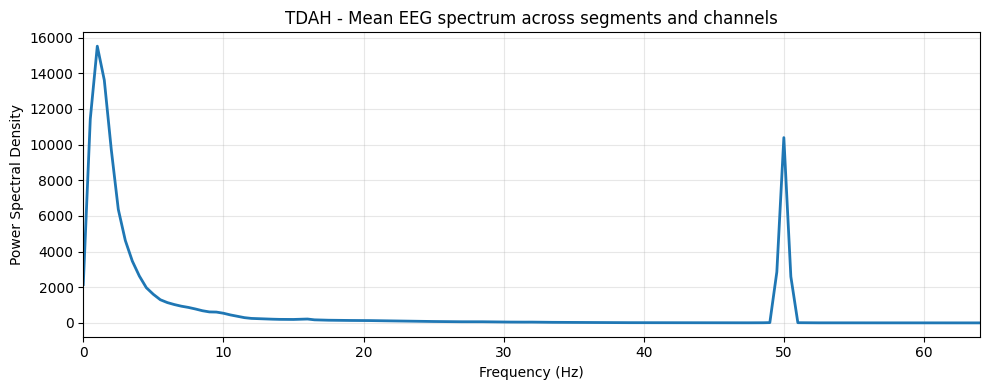

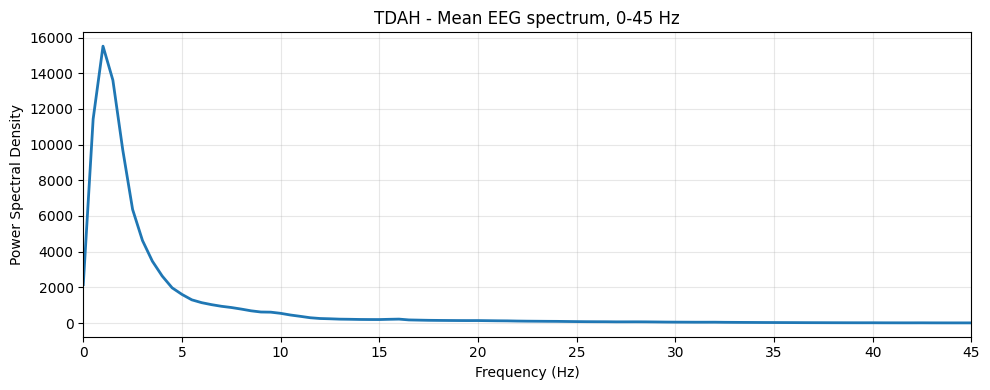

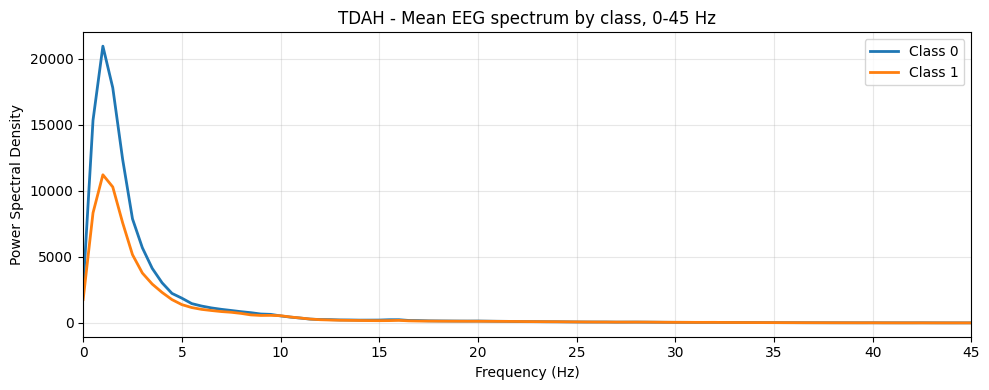


Bandas TDAH sugeridas
Delta     :   1.0 -   4.0 Hz | válida según Nyquist: True
Theta     :   4.0 -   8.0 Hz | válida según Nyquist: True
Alpha     :   8.0 -  13.0 Hz | válida según Nyquist: True
Beta      :  13.0 -  30.0 Hz | válida según Nyquist: True
Gamma low :  30.0 -  45.0 Hz | válida según Nyquist: True
